<a href="https://colab.research.google.com/github/aniimishra/FASHION-DATA-EDA/blob/main/Fashion_Data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape: (23472, 10)
<class 'pandas.core.frame.DataFrame'>
Index: 23472 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              23472 non-null  int64 
 1   Age                      23472 non-null  int64 
 2   Title                    19663 non-null  object
 3   Review Text              22628 non-null  object
 4   Rating                   23472 non-null  int64 
 5   Recommended IND          23472 non-null  int64 
 6   Positive Feedback Count  23472 non-null  int64 
 7   Division Name            23472 non-null  object
 8   Department Name          23472 non-null  object
 9   Class Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 2.0+ MB
None
        Clothing ID           Age        Rating  Recommended IND  \
count  23472.000000  23472.000000  23472.000000     23472.000000   
mean     918.486665     43.200707      4.195552   

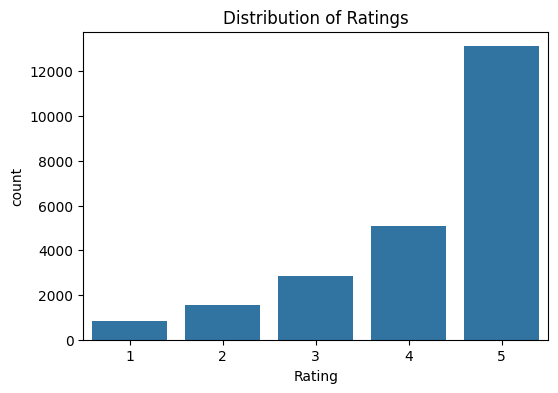

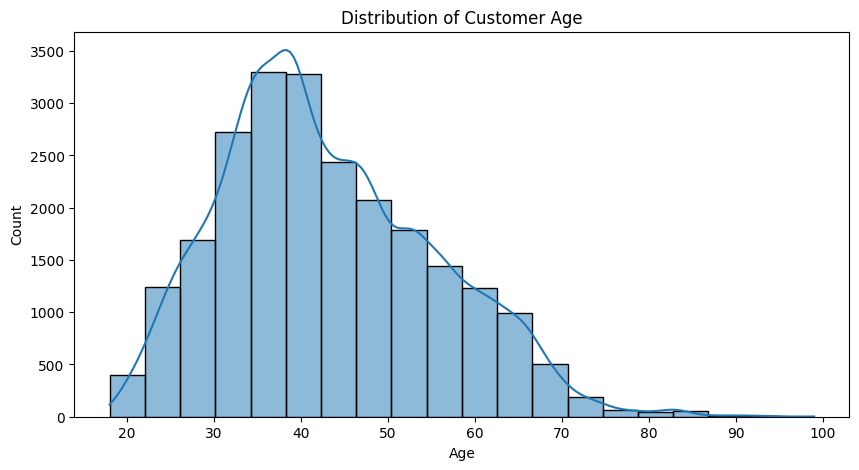

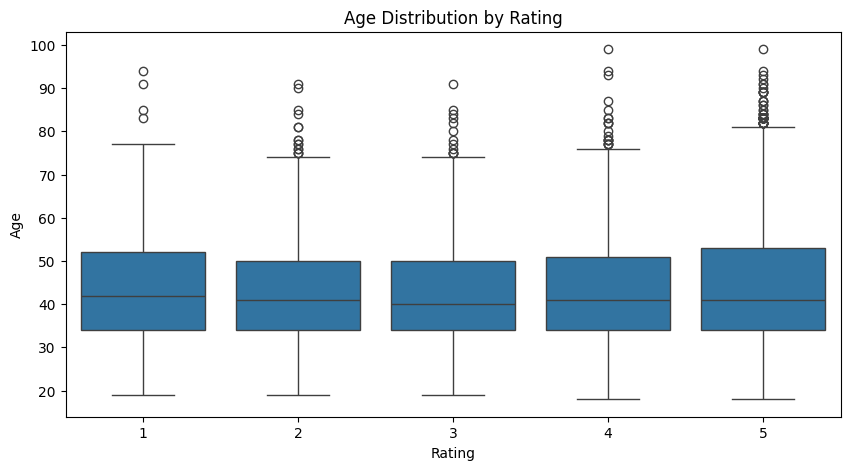

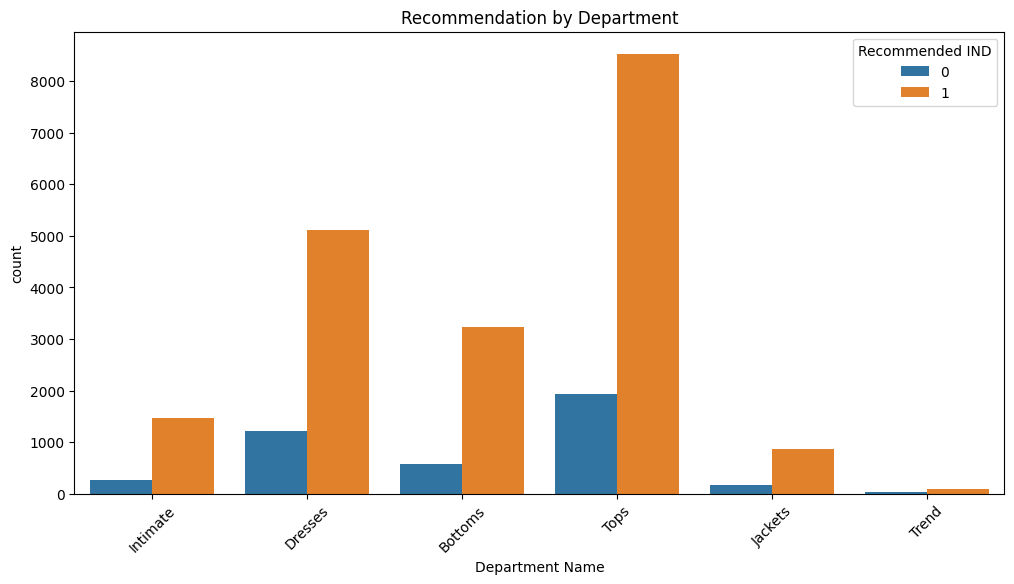


Sample Review Texts:
['I am in love with this top! it is so comfortable and lovely. it runs a touch big like most items of this brand.'
 "Well made gorgeous skirt that can be worn with heels and lace top or tee shirt and big jewelry. true to size. i am a 2/4 and the extra small was great. poofs out a bit but not like you're a fairy. i would say the blue (which i ordered) is more of a seafoam / mint green which is also lovely and spring time."
 'This is a great top. easy breezy and perfect for fall in miami. perfect top for spring too. love the whimsical pattern. a great addition to any wardrobe.'
 'Comfy and different. almost like a sweater fabric.'
 'Yep, i used to have a nice body, but now have the dreaded menopause stomach... and some excess baggage. this dress was very flattering. wore it today, easter sunday and had literally a dozen people seek me out to tell me how great the dress was or how nice i looked. it is a bright pink, think pepto bismol! heavy brocade type fabric plus 

3

In [ ]:
# 📦 Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 🧾 Load the data
df = pd.read_csv('/content/Womens Clothing E-Commerce Reviews.csv')

# 🧹 Clean the data
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')  # remove index column
df.dropna(subset=['Division Name', 'Department Name', 'Class Name'], inplace=True)

# 📊 Basic Info
print("Shape:", df.shape)
print(df.info())

print(df.describe())

# 🔍 Missing Values
print(df.isnull().sum())

# 📈 Univariate Analysis
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Rating')
plt.title('Distribution of Ratings')
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Customer Age')
plt.show()

# 📉 Bivariate Analysis
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Rating', y='Age')
plt.title('Age Distribution by Rating')
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Department Name', hue='Recommended IND')
plt.title('Recommendation by Department')
plt.xticks(rotation=45)
plt.show()

# 📦 Text Data Exploration
print("\nSample Review Texts:")
print(df['Review Text'].dropna().sample(5).values)
3

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Step 2: Load the dataset
df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")  # Use your actual CSV file

# Step 3: Select relevant features
features = ['Age', 'Rating', 'Department Name', 'Class Name']
target = 'Recommended IND'

df = df[features + [target]].dropna()  # Drop missing values for simplicity

# Step 4: Encode categorical variables
label_encoders = {}
for col in ['Department Name', 'Class Name']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Step 5: Define X and y
X = df[features]
y = df[target]

# Step 6: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Train a Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 8: Make predictions
y_pred = model.predict(X_test)

# Step 9: Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9256656017039404
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.81      0.80       863
           1       0.96      0.95      0.95      3832

    accuracy                           0.93      4695
   macro avg       0.87      0.88      0.88      4695
weighted avg       0.93      0.93      0.93      4695

Confusion Matrix:
 [[ 701  162]
 [ 187 3645]]


In [ ]:
import pandas as pd
import numpy as np
import nltk
from textblob import TextBlob
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv('/content/Womens Clothing E-Commerce Reviews.csv')


In [ ]:

# Fill missing values in 'Review Text' with empty strings
df['Review Text'] = df['Review Text'].fillna('')

# Create a function to get sentiment polarity
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

# Apply sentiment
df['Sentiment Score'] = df['Review Text'].apply(get_sentiment)

# Label the sentiment
def label_sentiment(score):
    if score > 0.1:
        return 'Positive'
    elif score < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Sentiment Score'].apply(label_sentiment)

# You can now inspect the new columns
print(df[['Review Text', 'Sentiment Score', 'Sentiment']].head())


                                         Review Text  Sentiment Score  \
0  Absolutely wonderful - silky and sexy and comf...         0.633333   
1  Love this dress!  it's sooo pretty.  i happene...         0.339583   
2  I had such high hopes for this dress and reall...         0.073675   
3  I love, love, love this jumpsuit. it's fun, fl...         0.550000   
4  This shirt is very flattering to all due to th...         0.512891   

  Sentiment  
0  Positive  
1  Positive  
2   Neutral  
3  Positive  
4  Positive  


/tmp/ipykernel_953/4224620772.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette='pastel')


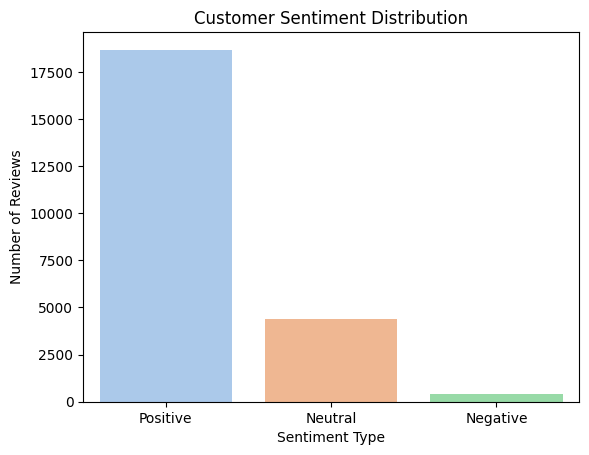

In [ ]:
sns.countplot(x='Sentiment', data=df, palette='pastel')
plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment Type")
plt.ylabel("Number of Reviews")
plt.show()


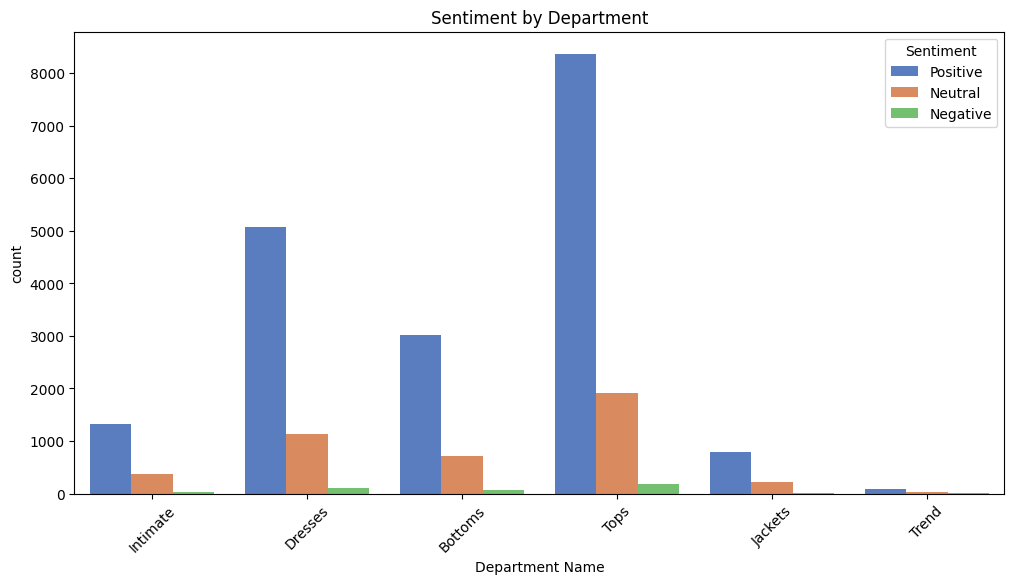

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Department Name', hue='Sentiment', palette='muted')
plt.title("Sentiment by Department")
plt.xticks(rotation=45)
plt.show()


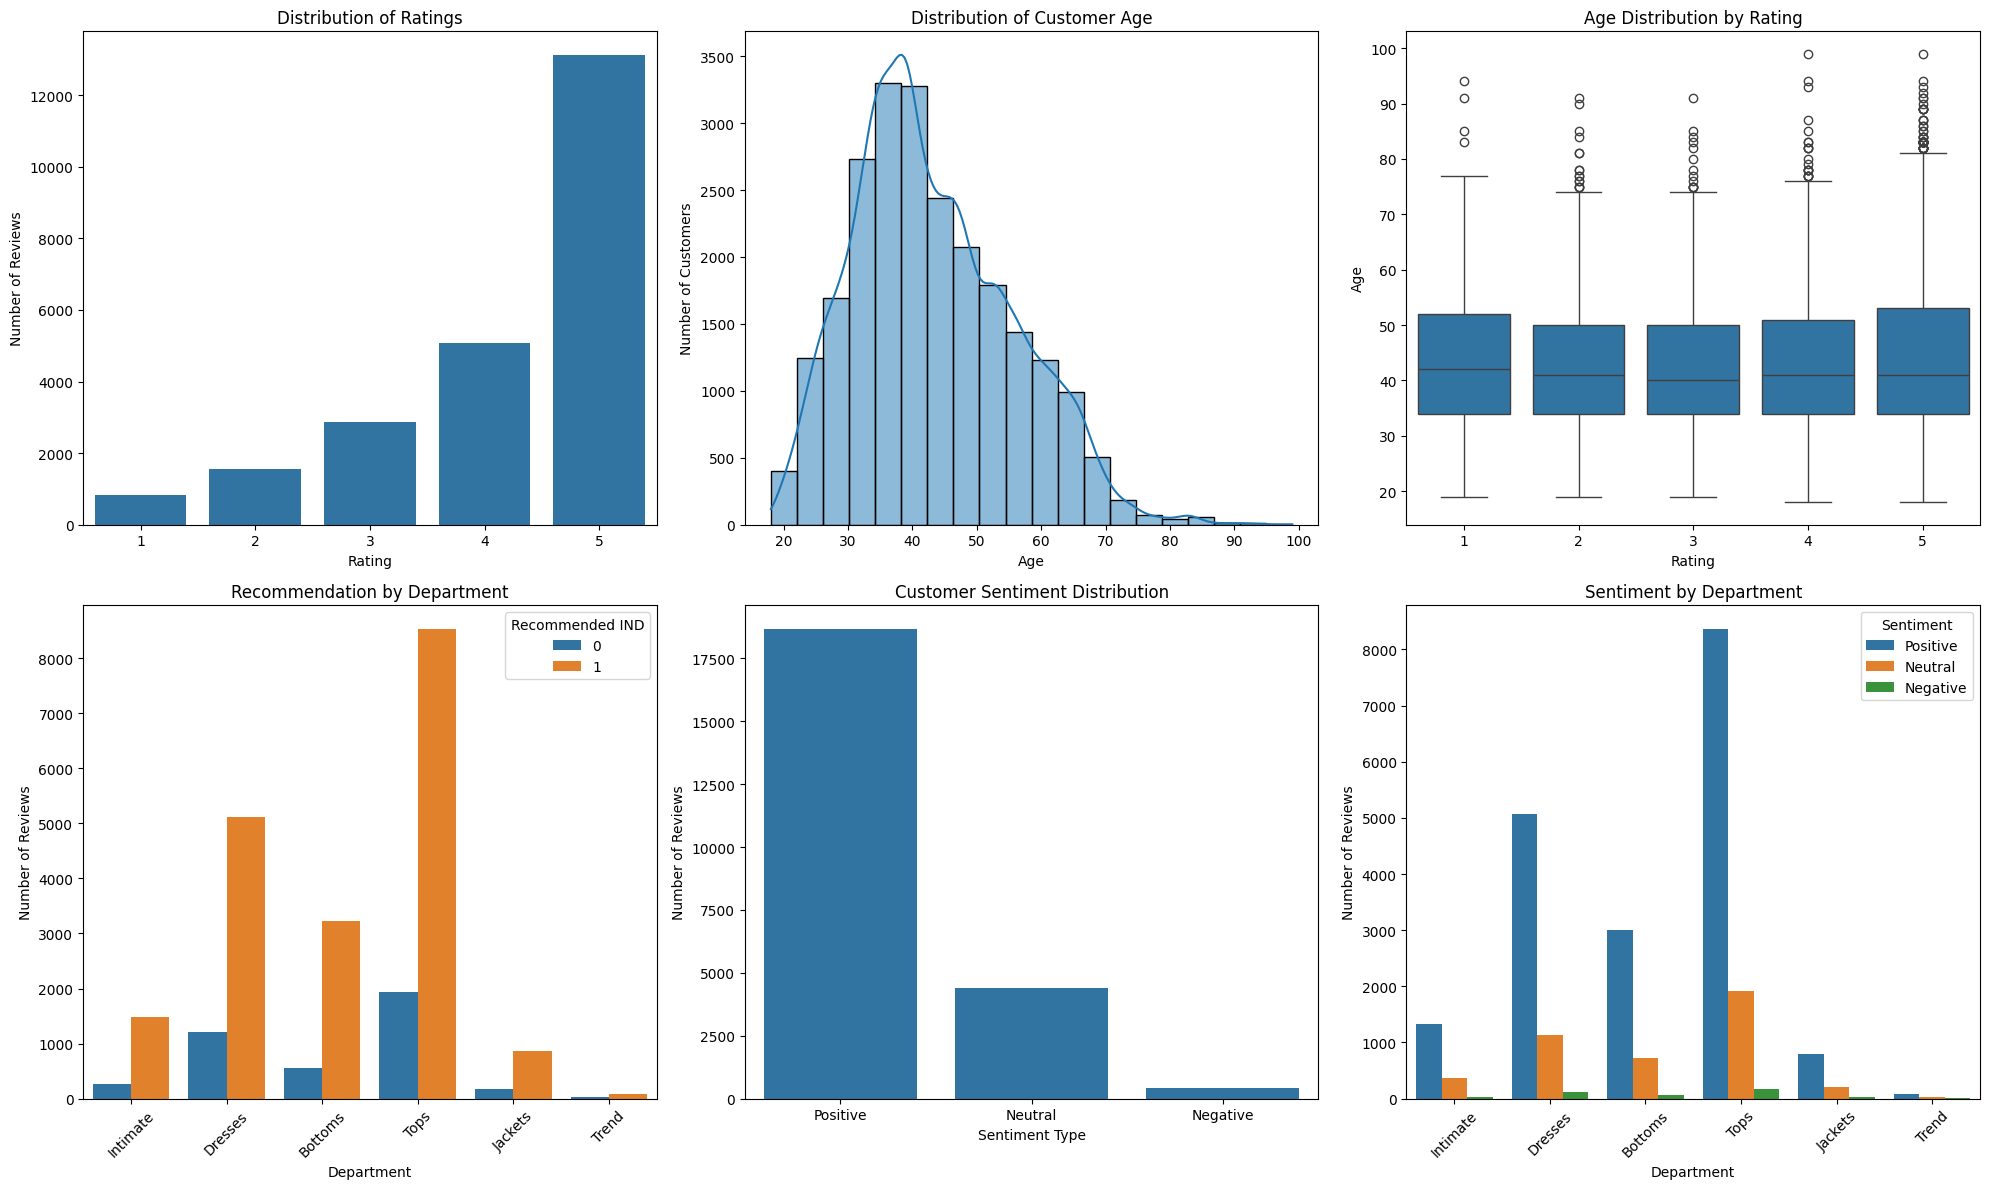

In [ ]:
# ============================================================
# 📊 ALL CHARTS ON A SINGLE SHEET
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1️⃣ Distribution of Ratings
sns.countplot(data=df, x='Rating', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Ratings')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Number of Reviews')

# 2️⃣ Distribution of Customer Age
sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Customer Age')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Number of Customers')

# 3️⃣ Age Distribution by Rating
sns.boxplot(data=df, x='Rating', y='Age', ax=axes[0, 2])
axes[0, 2].set_title('Age Distribution by Rating')
axes[0, 2].set_xlabel('Rating')
axes[0, 2].set_ylabel('Age')

# 4️⃣ Recommendation by Department
sns.countplot(
    data=df,
    x='Department Name',
    hue='Recommended IND',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Recommendation by Department')
axes[1, 0].set_xlabel('Department')
axes[1, 0].set_ylabel('Number of Reviews')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5️⃣ Customer Sentiment Distribution
sns.countplot(
    data=df,
    x='Sentiment',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Customer Sentiment Distribution')
axes[1, 1].set_xlabel('Sentiment Type')
axes[1, 1].set_ylabel('Number of Reviews')

# 6️⃣ Sentiment by Department
sns.countplot(
    data=df,
    x='Department Name',
    hue='Sentiment',
    ax=axes[1, 2]
)
axes[1, 2].set_title('Sentiment by Department')
axes[1, 2].set_xlabel('Department')
axes[1, 2].set_ylabel('Number of Reviews')
axes[1, 2].tick_params(axis='x', rotation=45)

# Adjust spacing
plt.tight_layout()

# Display everything on one sheet
plt.show()